## CODE U-NET FROM SCRATCH
```
Why U-Net?
Preserves spatial details through skip connections
Works well with limited data
Industry standard for medical and scientific segmentation

### 1. Imports

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms       
from torch.utils.data import DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt

```
Import	                Purpose
torch	                Core PyTorch - tensors, GPU support
torch.nn	        Neural network building blocks (Conv2d, ReLU, etc.)
transforms	        Image preprocessing (resize, convert to tensor)
DataLoader	        Batches data for training
datasets	        Access to OxfordIIITPet dataset
matplotlib.pyplot	Visualization
```

### 2. Dataset (IMPORTANT)

In [3]:
from torchvision.datasets import OxfordIIITPet

```
DATASET EXPLANATION
What is OxfordIIITPet Dataset?

The Oxford-IIIT Pet Dataset contains 7,349 images of 37 different cat and dog breeds. Each image comes with:
RGB image (the actual photo)
Segmentation mask (pixel-level labels)

Dataset Breakdown:
text
Total Images: 7,349
├── Training: ~3,680 images (split='trainval' actually combines both)
├── Validation: ~3,669 images
└── Test: Not officially separated (we need to split ourselves)

Split types:
- 'trainval': ALL images (7,349)
- 'train': Training portion only
- 'test': Test portion only

Dataset Structure:
OxfordIIITPet Dataset
├── images/
│   ├── Abyssinian_1.jpg
│   ├── Abyssinian_2.jpg
│   ├── ...
│   └── Yorkshire_Terrier_100.jpg
│
└── annotations/
    ├── trimaps/
    │   ├── Abyssinian_1.png
    │   ├── Abyssinian_2.png
    │   ├── ...
    │   └── Yorkshire_Terrier_100.png
    └── ...

What's Inside the Mask Image:
The mask images (trimaps) have 3 distinct pixel values:

Pixel Value	  Meaning	        Visual Representation
1	          Pet (foreground)	The cat or dog pixels
2	          Background	        Everything else
3	          Border	        Boundary between pet and background

Later this 1,2,3 is converted to 0,1,2 for loss function.
Important: The mask is a single-channel image (grayscale) where each pixel is an integer (1, 2, or 3), NOT RGB values 0-255(3 channels).

So each pixel tells us exactly what it belongs to!
Why This Dataset?
Your Happy/Sad Dataset	     OxfordIIITPet
❌ No masks	             ✅ Has masks
❌ Can't do segmentation     ✅ Perfect for segmentation
❌ Only classification	     ✅ Pixel-level labels

Visual Example of Mask:

Original RGB Image:           Mask Image (values):
┌─────────────────┐           ┌─────────────────┐
│     🐱          │           │ 2 2 2 2 2 2 2 2 │
│   on carpet     │    →      │ 2 1 1 1 1 1 2 2 │
│                 │           │ 2 1 1 1 1 1 2 2 │
└─────────────────┘           │ 2 2 2 2 2 2 2 2 │
                              └─────────────────┘
                              
Pixel values:
1 = Cat pixels (foreground)
2 = Background (carpet)
3 = Border (not shown, between cat and background)
```

### 2.1 Load dataset:
```
Current code uses ALL data for training (not good)
Should split into train/val/test for proper evaluation

In [4]:
# Transform original images
transform = transforms.Compose([              # Define a series of transformations to apply to the images in the dataset
    transforms.Resize((128,128)),             # Resize images to a fixed size (128x128 in this case) to ensure uniform input size for the model
    transforms.ToTensor()                     # Convert PIL Image to tensor and normalize pixel values to [0, 1]
])

# Transform mask images 
target_transform = transforms.Compose([       # For segmentation masks, we typically want to convert them to tensors without normalization, as they represent class labels rather than pixel intensities
    transforms.Resize((128,128)),
    transforms.PILToTensor()                  # Convert PIL Image to tensor without normalization because segmentation masks are typically in the form of integer labels and we want to preserve those values for training the model
])

dataset = OxfordIIITPet(                      # Create an instance of the OxfordIIITPet dataset      
    root='./data',                            # Specify the root directory where the dataset will be downloaded
    split='trainval',                         # (train + validation) Use the 'trainval' split mechanism to include both training and validation data in other words, we are using the entire dataset for training and for validation we can later split it ourselves if needed
    target_types='segmentation',              # Specify that we want to load segmentation masks as the target labels for the dataset
    download=True, 
    transform=transform,                      # Apply the defined transformations to the images
    target_transform=target_transform         # Apply the defined transformations to the segmentation masks (target labels)
)

loader = DataLoader(dataset, batch_size=8, shuffle=True)       # Create a DataLoader to load the dataset in batches of 8 and shuffle the data for training

# DataLoader setup:
# batch_size=8: Process 8 image-mask pairs at once
# shuffle=True: Randomize order each epoch
# What one batch contains:
# images shape: (8, 3, 128, 128)  # 8 RGB images
# masks shape:  (8, 1, 128, 128)  # 8 masks (1 channel)

```
What happens to RGB Image:

Original: PIL Image (H, W, 3) with values 0-255
    ↓ Resize
(128, 128, 3) still 0-255
    ↓ ToTensor
(3, 128, 128) with values 0.0-1.0 (float) , normalized

Example: Pixel [100, 200] originally RGB (150, 100, 50)
After transform: tensor([0.588, 0.392, 0.196])


What happens to Mask:

Original: PIL Image (H, W) with values 1,2,3 (integers)
    ↓ Resize
(128, 128) still integers 1,2,3
    ↓ PILToTensor
(1, 128, 128) with values 1,2,3 (integers, NOT normalized!, remains same values as 1,2,3)

Example: Mask pixel at [100, 200] originally value 1 (pet)
After transform: tensor([[1]]) for that position

### 3. U-Net Building Blocks

#### Double Conv
This is the building block of the U-Net model. It consists of two convolutional layers with ReLU activation in between and it will be used multiple times in the U-Net model.

This double convolution block will maintain the output shape same as the input shape and channel size will be output channel size.


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),                 # First convolutional layer: takes in_ch input channels and produces out_ch output channels, with a kernel size of 3 and padding of 1 to maintain spatial dimensions of the input same as output
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()                                               # output shape remains the same as input shape due to padding, and the number of channels is out_ch after the first convolution and remains out_ch after the second convolution
        )
    def forward(self, x):
        return self.conv(x)

```
What DoubleConv does:

Input: (C_in, H, W)
    ↓
Conv2d (3×3, padding=1): (C_out, H, W)  ← preserves size
    ↓
ReLU: (C_out, H, W)  ← adds non-linearity
    ↓
Conv2d (3×3, padding=1): (C_out, H, W)  ← second conv
    ↓
ReLU: (C_out, H, W)
    ↓
Output: (C_out, H, W)  ← same size, more features
Why two convolutions?

First conv: Detect basic patterns
Second conv: Refine and combine patterns
Two layers = more expressive power
Padding=1: Keeps spatial size same (H,W unchanged) 

#### U-Net Model

In [6]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()


        # Encoder Path (Contracting or Downsampling Path)
        self.down1 = DoubleConv(3, 64)            # First layer of the encoder takes 3 input channels (RGB image) and produces 64 output channels (64, 128, 128): 64 feature maps of size 128x128
        self.pool1 = nn.MaxPool2d(2)              # Max pooling layer with a kernel size of 2, which reduces the spatial dimensions by half (128x128 to 64x64) while keeping the number of channels the same (64)
        
        self.down2 = DoubleConv(64, 128)          # Output shape: (128, 64, 64)
        self.pool2 = nn.MaxPool2d(2)              # Output shape: (128, 32, 32)
        
        
        # Bottleneck
        self.middle = DoubleConv(128, 256)        # Output shape: (256, 32, 32) : The bottleneck layer takes the output from the last encoder layer and processes it to capture the most abstract features of the input image, with 256 feature maps of size 32x32
        

        # Decoder Path (Expanding or Upsampling Path)
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)       # Output shape: (128, 64, 64), Transposed convolutional layer that upsamples the feature maps from the bottleneck, reducing the number of channels from 256 to 128 and doubling the spatial dimensions from 32x32 to 64x64, 2 is the kernel size and stride=2 means it will upsample by a factor of 2
        self.conv1 = DoubleConv(256, 128)                          # Output shape: (128, 64, 64), DoubleConv layer with 256 input channels and 128 output channels , the input channels are 256 because we will concatenate the output of the upsampling layer (128 channels) with the corresponding feature maps from the encoder path (128 channels) which gives us a total of 256 input channels for this DoubleConv layer (skip connection)
        
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)        # Output shape (64, 128, 128), upsample size by 2
        self.conv2 = DoubleConv(128, 64)                           # Output shape (64, 128, 128), similar skip connection

        self.final = nn.Conv2d(64, 3, 1)                           # It is just a normal convolutional layer with 64 input channels and 3 output channels, Output shape (3, 128, 128), Final convolutional layer that takes the output from the last decoder layer (64 channels) and produces the final output with 3 channels (3 class classified) (for RGB segmentation mask), with a kernel size of 1 to maintain the spatial dimensions of the input and output the same (128x128)

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)                            # output shape: (64, 128, 128)
        p1 = self.pool1(d1)                           # output shape: (64, 64, 64)
        
        d2 = self.down2(p1)                           # output shape: (128, 64, 64)
        p2 = self.pool2(d2)                           # output shape: (128, 32, 32) 
        
        # Bottleneck
        mid = self.middle(p2)                         # output shape: (256, 32, 32)
        
        # Decoder with skip connections
        u1 = self.up1(mid)                            # output shape: (128, 64, 64)
        u1 = torch.cat([u1, d2], dim=1)               # output shape: (256, 64, 64) , Concatenate the upsampled feature maps (128 channels) with the corresponding feature maps from the encoder path (128 channels) along the channel dimension (dim=1) dim =1 because we are concatenating along the channel dimension , resulting in a total of 256 channels for the input to the next DoubleConv layer
        u1 = self.conv1(u1)                           # output shape: (128, 64, 64) , Process the concatenated feature maps through the DoubleConv layer to refine the features and reduce the number of channels back to 128
        
        u2 = self.up2(u1)                             # output shape: (64, 128, 128) , Upsample the feature maps again to increase the spatial dimensions back to 128x128 and reduce the number of channels to 64
        u2 = torch.cat([u2, d1], dim=1)               # output shape: (128, 128, 128) , skip connection with the first layer of encoder path
        u2 = self.conv2(u2)                           # output shape: (64, 128, 128) 

        return self.final(u2)                         # output shape: (3, 128, 128) , Pass the output through the final convolutional layer to produce the final segmentation mask with 3 channels (for RGB) and the same spatial dimensions as the input image (128x128)

```
Visualizing Skip Connections:            
x (3,128,128)
    ↓
d1  ──────────────────────────────────┐
    ↓                                 │        Encoder Path   
p1                                    │
    ↓                                 │
d2  ──────────────────────────┐       │
    ↓                         │       │
p2                            │       │
    ↓                         │       │
mid                           │       │
    ↓                         │       │
u1 ←──────────────────────────┘       │
    ↓                                 │         Decoder Path
u2 ←──────────────────────────────────┘
    ↓
final

Skip connections preserve spatial details!

### 4. Training Setup

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'   # Set the device to GPU if available, otherwise use CPU
print(f'Using device: {device}')
model = UNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


```
Why CrossEntropyLoss?

Multi-class classification (3 classes)
Each pixel independently classified
Output shape: (B, 3, H, W) → (B, H, W) predictions

### 5. Training Loop

In [8]:
for epoch in range(2):
    for images, masks in loader:
        images = images.to(device)
        
        masks = masks.squeeze(1)                          # Remove the channel dimension from the masks tensor, changing its shape from (batch_size, 1, height, width) to (batch_size, height, width) because CrossEntropyLoss expects the target masks to be in the shape of (batch_size, height, width) where each pixel value represents the class label for that pixel thats single channel
        masks = masks - 1                                 # Subtract 1 from the labels to make them zero-based (assuming the original labels are 1, 2, 3 for the three classes, we want them to be 0, 1, 2 for CrossEntropyLoss) because CrossEntropyLoss expects class labels to be zero-based (starting from 0), and if the original labels are 1, 2, 3 for the three classes, we need to subtract 1 to convert them to 0, 1, 2 which is the format expected by CrossEntropyLoss
        masks = masks.long().to(device)                   # Convert the masks to long type (integer type) and move them to the same device as the model (GPU or CPU) because CrossEntropyLoss expects the target masks to be of type long (integer type) where each pixel value is a class label

        outputs = model(images)                           # Output shape: (batch_size, num_classes, height, width)= (8, 3, 128, 128) because the model's final layer produces an output with 3 channels (logits for each of the 3 classes) and the same spatial dimensions as the input image (128x128)
        loss = criterion(outputs, masks)                  # copare the model's output with the ground truth masks to compute the loss, CrossEntropyLoss is used for multi-class segmentation tasks where the target masks contain class labels for each pixel                  

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")           

Epoch 1, Loss: 0.7058309316635132
Epoch 2, Loss: 0.5653833150863647


```
Why Mask Has 1 Channel vs Output Has 3 Channels
The Confusion Explained:
Mask (Ground Truth): (B, 1, H, W)

Single channel containing class indices (1, 2, or 3) [Final class for each pixel]

Each pixel stores just ONE number (which class it belongs to)

Model Output: (B, 3, H, W)

Three channels containing logits (raw scores) for each class [one of them is correct, actual mask class for that perticular pixel]

For each pixel, we have 3 numbers representing confidence (logits or raw scores of probabilities) for class 1, 2, and 3

Concrete Example:
Let's say we have a single pixel at position (y=50, x=100):

Ground Truth Mask (1 channel):

mask[0, 0, 50, 100] = 1    # This pixel belongs to class 1 (pet) [actual mask class for that perticular pixel]

Model Output for this Pixel (3 channels):

outputs[0, 0, 50, 100] = 2.5  # Score for class 1 (pet)
outputs[0, 1, 50, 100] = 0.2  # Score for class 2 (background)
outputs[0, 2, 50, 100] = -1.3 # Score for class 3 (border)

How Loss Works:
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, masks)  # outputs: (B,3,H,W), masks: (B,H,W)

CrossEntropyLoss automatically:
Takes the 3-channel output (logits)
Applies softmax to get probabilities
Picks the probability of the correct class (from mask)
Computes negative log of that probability

Step-by-Step Loss Calculation for Our Example:
# Step 1: Model output for one pixel
logits = [2.5, 0.2, -1.3]
# Step 2: Apply softmax
exp_logits = [exp(2.5)=12.18, exp(0.2)=1.22, exp(-1.3)=0.27]
sum_exp = 13.67
probabilities = [12.18/13.67=0.89, 1.22/13.67=0.09, 0.27/13.67=0.02]

# Step 3: Ground truth mask says class 1 (index 0)
# Step 4: Loss = -log(probability of correct class)
loss = -log(0.89) = 0.12     # Very low loss (model confident and correct)

PART 4: Understanding argmax
What argmax Does:
preds = model(images).argmax(1)
# After model(images): shape (B, 3, H, W)
# After argmax(1): shape (B, H, W)    [argmax takes 1 class per pixel]
argmax(1) finds which channel has the highest value for each pixel.

Example for Single Pixel: 
Model output for pixel (y=50, x=100):
Channel 0 (class 1):  2.5
Channel 1 (class 2):  0.2
Channel 2 (class 3): -1.3

argmax(1) compares [2.5, 0.2, -1.3] → picks index 0
Result: 0 (meaning predicted class is 1)

Full Example for a 2×2 Region:
Model Output (3 channels):
Channel 0 (class 1):         Channel 1(class 2):          Channel 2(class 3):
[2.5, 0.1]                   [0.2, 1.5]                   [-1.3, 0.8]
[1.2, 3.0]                   [0.5, 0.3]                   [0.2, -0.5]

argmax(1) output (1 channel):
[0, 1]   ← (pixel0: class0 highest, pixel1: class1 highest)
[0, 0]   ← (pixel2: class0 highest, pixel3: class0 highest)

Final prediction mask:
[1, 2]   ← Class indices (1 and 2, because we add 1 to indices)
[1, 1]   ← Or in our case, we use indices 0,1,2 directly

### 6. VISUALIZATION
Its not a validation step, its a visualization step where we take a batch of images and masks from the DataLoader and visualize them if the model is performing well

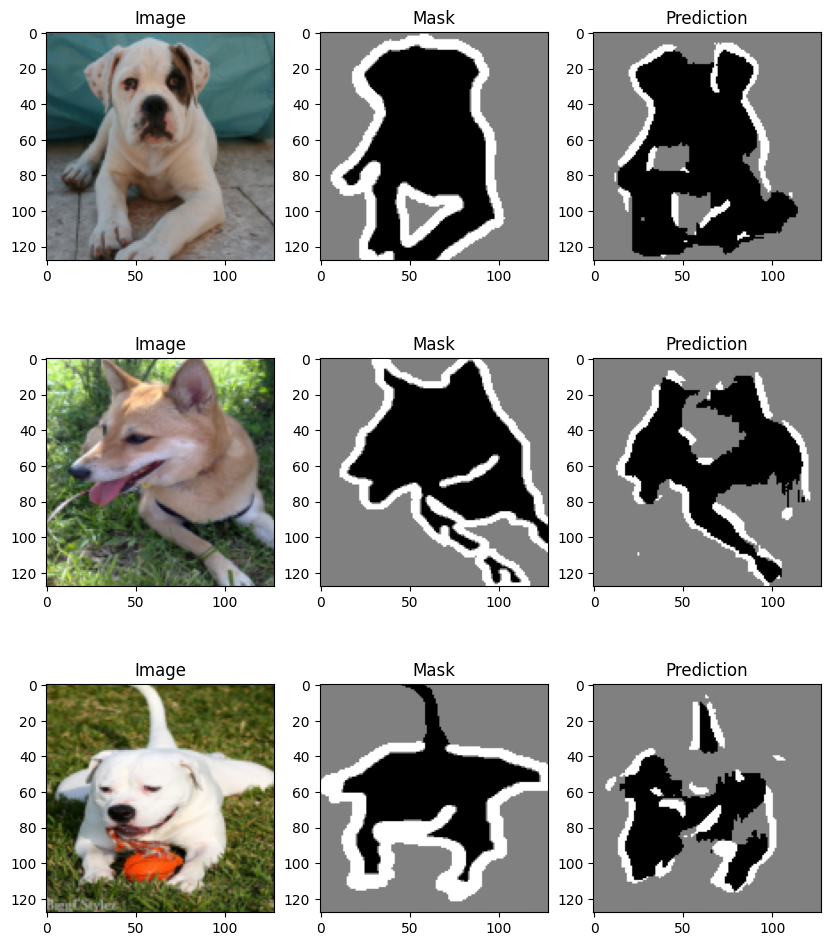

In [ ]:
images, masks = next(iter(loader))            # Get a batch of images and masks from the DataLoader for visualization
# images: on CPU by default 
# masks: on CPU by default
images = images.to(device)                    # Move the images only to the GPU for evaluation or prediction

with torch.no_grad():                                # Use torch.no_grad() to disable gradient computation during evaluation
    # Move results back to CPU
    preds = model(images).argmax(1).cpu()            # Get the predicted class for each pixel by taking the argmax across the channel dimension (dim=1) of the model's output, which gives us a tensor of shape (batch_size, height, width) where each pixel value represents the predicted class label for that pixel, and move it back to CPU for visualization

plt.figure(figsize=(10,12))

for i in range(3):                                      # Plot the first 3 images, masks, and predictions
    plt.subplot(3,3,i*3+1)                              # Plot the original image in the first column of the grid 
    plt.imshow(images[i].cpu().permute(1,2,0))          # ← NEED .cpu() because images is on GPU!, Display the image in RGB format by permuting the channel dimension to the last position, permute(1,2,0) means we are changing the order of dimensions from (channels- 0, height- 1, width- 2) to (height, width, channels) which is the format expected by matplotlib for displaying images 
    plt.title("Image")

    plt.subplot(3,3,i*3+2)                             # Plot the mask in the second column of the grid
    plt.imshow(masks[i].squeeze(), cmap='gray')        # ← NO .cpu() because masks never left CPU!, Display the mask in grayscale, squeeze() is used to remove the channel dimension from the mask tensor, changing its shape from (1, height, width) to (height, width) which is the format expected by matplotlib for displaying images, and cmap='gray' is used to display the mask in grayscale since it contains class labels rather than RGB values and without grayscale it would be hard to visualize the different classes in the mask
    plt.title("Mask")

    plt.subplot(3,3,i*3+3)                             # ← NO .cpu() because we already moved to CPU!, Plot the predicted mask in the third column of the grid
    plt.imshow(preds[i], cmap='gray')
    plt.title("Prediction")

plt.show()                 

```
Why We Use cmap='gray' for Both Mask and Prediction

The Real Reason:
Both masks and preds contain class indices (0, 1, 2, etc.), not RGB colors!

# mask values (ground truth):
# Class 1 (pet)    = pixel value 1
# Class 2 (background) = pixel value 2
# Class 3 (border) = pixel value 3

# preds values (predictions):
# Class 0 (pet)    = pixel value 0  (after argmax)
# Class 1 (background) = pixel value 1
# Class 2 (border) = pixel value 2

Visualizing Class Indices as Colors:
# If we didn't use cmap='gray', matplotlib would use default colormap
# which might assign random colors to different numbers
# This could be confusing because:
# - Image 1: class 0 might appear red
# - Image 2: class 0 might appear blue (same class, different color!)

# Using cmap='gray' ensures:
# - Lower numbers = darker
# - Higher numbers = lighter
# - Consistent across all images!

### 7. (OPTIONAL) Overlay
Overlay is the combination of the original image and the predicted mask to get a better understanding of the model's predictions.
This is done by adding the predicted mask to the original image with an alpha value of 0.5 that makes the predicted mask semi-transparent.

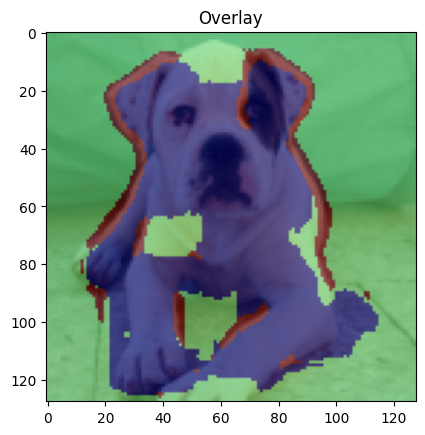

In [15]:
plt.imshow(images[0].cpu().permute(1,2,0))            # Display the original image in RGB format
plt.imshow(preds[0], alpha=0.5, cmap='jet')           # Overlay the predicted mask on the original image with transparency and a jet colormap, alpha=0.5 means 50% transparency, and cmap='jet' is used to apply a colormap to the predicted mask to make it easier to visualize the different classes in the mask when overlaid on the original image, jet colormap will assign different colors to different class labels in the predicted mask, making it easier to distinguish between the classes when overlaid on the original image
plt.title("Overlay")
plt.show()


### SUMMARY:
```
Component	            What It Does
Dataset	Oxford              Pet images with segmentation masks
DoubleConv	            Extract features with two conv layers
Encoder	                    Downsample, capture context
Bottleneck	            Most abstract features
Decoder	                    Upsample, restore spatial detail
Skip Connections	    Preserve spatial information
Training	            Learn to classify each pixel
Visualization	            Compare predictions with ground truth

Pixel Classification:
Each pixel independently classified into 3 classes
Output has 3 channels because 3 classes
argmax picks the class with highest score

Remember: The magic of U-Net is that it preserves spatial information through skip connections, allowing it to classify each pixel accurately while understanding the overall image context!

The U-Net Advantage:
Encoder: "What is in the image?" (semantic understanding)
Decoder: "Where exactly is it?" (spatial precision)
Skip Connections: Combine both for perfect segmentation!

Remember: The magic of U-Net is that it preserves spatial information through skip connections, allowing it to classify each pixel accurately while understanding the overall image context!
This is why U-Net is so powerful - it never forgets the spatial details while understanding the big picture!